# MRNet — Reproduction (Apple Silicon / MPS)

Reproducing **Bien, Rajpurkar, Ball et al. (2018)**, *Deep-learning-assisted diagnosis for knee MRI: development and retrospective validation of MRNet*, PLOS Medicine 15(11): e1002699.

## What the paper does (and what we rebuild here)

| Rung | Unit | Collapse rule |
|---|---|---|
| slice | one 256×256 cross-section | ImageNet-pretrained **AlexNet** → 256-d feature vector |
| series | stack of same-plane slices | **max-pool across the slice axis** → one 256-d vector → one logit |
| study | 3 series (axial / coronal / sagittal) | **logistic regression** = learned weighted vote → final score |

Three binary tasks (**abnormal**, **ACL tear**, **meniscus tear**) × three planes = **9 independently trained CNNs**, then 3 logistic-regression combiners (one per task).

## Numbers we are trying to hit (paper, internal validation set, n=120)

| Task | Paper AUC |
|---|---|
| Abnormality | 0.937 |
| ACL tear | 0.965 |
| Meniscus tear | 0.847 |

Meniscus is expected to be the weakest — that's a real property of the task, not a bug in your run.

## Notebook layout

1. Config + device
2. Data (real MRNet, or a **synthetic sandbox** so the whole pipeline runs before the download lands)
3. Labels
4. Dataset + volume-level augmentation
5. Model (`MRNet`, with a swappable pooling rule — default `max` = faithful)
6. Train / eval loops
7. Train all 9 CNNs
8. Per-series AUCs
9. Logistic-regression combiner → final AUCs vs paper
10. ROC curves + combiner-weight interpretability check
11. Phase 2 roadmap (our angle)

> **Kernel:** use `/Users/atharvax/dev/ml-env/.venv` (the `ml-env` Jupyter kernel).

## 0. Getting the data from Redivis (AIMI)

The dataset lives at `redivis.user("aimi").dataset("mrnet_knee_mri_s:4a2c:v1_0")`. Read access to
metadata worked without a token; if a call 401s, mint one at
*redivis.com → workspace → settings → API tokens* and `export REDIVIS_API_TOKEN=…` before launching
Jupyter. Install with `uv pip install redivis`.

**The dataset has 8 tables, and the starter snippet only touches one of them:**

| Table | Rows | What it is |
|---|---|---|
| `train:5wjf` | 3,390 | **file index only** — `file_id, file_name, size, added_at, md5_hash` |
| `valid` | 360 | same, for the 120-study validation split |
| `train-abnormal`, `train-acl`, `train-meniscus` | 1,129 each | **the labels** |
| `valid-abnormal`, `valid-acl`, `valid-meniscus` | 119 each | the labels |

Three traps, all of which bite silently:

1. **`table.to_pandas_dataframe()` on `train` gives you no labels.** That table is a file manifest —
   1,130 studies × 3 planes of `.npy` filenames. The labels are in the six *separate* `*-abnormal` /
   `*-acl` / `*-meniscus` tables. The snippet's `max_results=100` also caps you at 100 rows; drop it
   for the real pull.

2. **Redivis ate the first row of every label CSV.** The originals are headerless
   (`0000,1`), so header inference turned row 0 into the *column names*: `train-abnormal` comes back
   with columns `('_0000', '_1')` and 1,129 rows instead of 1,130. The lost row is recoverable —
   it's sitting in the column names — which is what `rebuild_labels()` below does. Skip this and
   study `0000` (and `1130` in valid) vanish from your data entirely.

3. **Check your download actually completed.** The bulk zips can truncate mid-write with no error.
   `verify_dataset()` below counts files per plane and confirms every volume loads as
   `(S, 256, 256) uint8`. Run it before you trust a training run.

The cell below is idempotent: it rebuilds the six label CSVs, fetches whichever image files are
missing, and verifies the result into the standard MRNet layout at `CFG.data_root`.

In [19]:
# --- one-off: assemble MRNet-v1.0/ from Redivis --------------------------------
# Safe to re-run: skips planes that are already complete.
import numpy as np, pandas as pd
from pathlib import Path

DATASET  = "mrnet_knee_mri_s:4a2c:v1_0"
DEST     = Path("./MRNet-v1.0")
_TASKS   = ["abnormal", "acl", "meniscus"]
_PLANES  = ["axial", "coronal", "sagittal"]
_EXPECT  = {"train": (1130, 0, 1129), "valid": (120, 1130, 1249)}


def rebuild_labels(dest=DEST, dataset=DATASET):
    """Six headerless CSVs, with the row Redivis turned into column names put back."""
    import redivis
    d = redivis.user("aimi").dataset(dataset)
    dest.mkdir(parents=True, exist_ok=True)
    out = {}
    for split in ("train", "valid"):
        for task in _TASKS:
            t = d.table(f"{split}-{task}")
            cols = [v["name"] for v in t.list_variables()]
            df = t.to_pandas_dataframe(progress=False)          # no max_results -> all rows
            # column names encode the eaten row: ('_0000', '_1') -> study 0000, label 1
            lost = pd.DataFrame({"study_id": [cols[0].lstrip("_").zfill(4)],
                                 "label":    [int(cols[1].lstrip("_"))]})
            rows = pd.DataFrame({"study_id": df[cols[0]].astype(str).str.zfill(4),
                                 "label":    df[cols[1]].astype(int)})
            csv = (pd.concat([lost, rows], ignore_index=True)
                     .sort_values("study_id").reset_index(drop=True))
            n, lo, hi = _EXPECT[split]
            assert csv.study_id.is_unique, f"{split}-{task}: duplicate study ids"
            assert sorted(int(i) for i in csv.study_id) == list(range(lo, hi + 1)), \
                   f"{split}-{task}: ids are not {lo:04d}..{hi:04d}"
            csv.to_csv(dest / f"{split}-{task}.csv", header=False, index=False)
            out[(split, task)] = csv
            print(f"  {split}-{task:9s} n={len(csv):5d}  pos={csv.label.sum():4d} "
                  f"({csv.label.mean():.3f})   restored {lost.study_id[0]}={lost.label[0]}")
    return out


def fetch_images(split, dest=DEST, dataset=DATASET):
    """Download a split's .npy files unless the plane folders are already complete."""
    import redivis
    n, _, _ = _EXPECT[split]
    root = dest / split
    have = {p: len(list((root / p).glob("*.npy"))) if (root / p).is_dir() else 0 for p in _PLANES}
    if all(v == n for v in have.values()):
        print(f"  {split}: already complete ({n} per plane) — skipping download")
        return
    print(f"  {split}: have {have}, want {n} per plane — downloading…")
    root.mkdir(parents=True, exist_ok=True)
    redivis.user("aimi").dataset(dataset).table(split).download_files(str(root), overwrite=True)


def verify_dataset(dest=DEST, sample=40, seed=0):
    """Count files per plane and confirm a sample of volumes loads as (S,256,256) uint8."""
    import random
    rng, ok = random.Random(seed), True
    for split, (n, lo, hi) in _EXPECT.items():
        ids = [f"{i:04d}" for i in range(lo, hi + 1)]
        for plane in _PLANES:
            d = dest / split / plane
            missing = [i for i in ids if not (d / f"{i}.npy").exists()]
            flag = "OK " if not missing else f"MISSING {len(missing)}"
            print(f"  {split:5s} {plane:9s} {len(list(d.glob('*.npy'))):5d}/{n}  {flag}"
                  + (f"  e.g. {missing[:5]}" if missing else ""))
            ok &= not missing
            for i in rng.sample([x for x in ids if x not in missing], min(sample, n - len(missing))):
                v = np.load(d / f"{i}.npy")
                if not (v.ndim == 3 and v.shape[1:] == (256, 256) and v.dtype == np.uint8):
                    print(f"    BAD {split}/{plane}/{i}.npy -> {v.shape} {v.dtype}"); ok = False
    for split in _EXPECT:
        for task in _TASKS:
            if not (dest / f"{split}-{task}.csv").exists():
                print(f"  missing {split}-{task}.csv"); ok = False
    print("\ndataset verified — ready to train" if ok else "\nDATASET INCOMPLETE (see above)")
    return ok


# Uncomment to run. rebuild_labels() is seconds; fetch_images() is ~7 GB for train.
# print("labels:");  rebuild_labels()
# print("images:");  [fetch_images(s) for s in ("train", "valid")]
# print("verify:");  verify_dataset()

ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-126' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/atharvax/dev/ml-env/.venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-127' coro=<Kernel.shell_main() running at /Users/atharvax/dev/ml-env/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/atharvax/dev/ml-env/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x11d909140>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object Kernel.shell_main at 0x11d909140>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='

## 1. Config, imports, device

Everything you'd want to tweak lives in `CFG`. Start with `QUICK=True` to smoke-test the whole
pipeline end-to-end in a couple of minutes, then flip it off for the real run.

In [20]:
import os, sys, json, math, random, time, warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models import alexnet, AlexNet_Weights
from torchvision.transforms import InterpolationMode
import torchvision.transforms.v2.functional as TF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore", category=UserWarning)

PLANES = ["axial", "coronal", "sagittal"]
TASKS  = ["abnormal", "acl", "meniscus"]

@dataclass
class Config:
    # --- data ---
    data_root: str = "./MRNet-v1.0"      # real dataset root (contains train/ valid/ *.csv)
    use_synthetic: bool = False           # auto-flipped to True below if real data is missing
    synth_root: str = "./mrnet_synthetic"

    # --- run size ---
    quick: bool = True                    # smoke test: few studies, 1 epoch
    epochs: int = 10                      # real run
    max_train_studies: int = 0            # 0 = all
    max_valid_studies: int = 0

    # --- optimisation (paper: Adam, lr 1e-5) ---
    lr: float = 1e-5
    weight_decay: float = 0.01
    grad_clip: float = 0.0                # 0 = off

    # --- model ---
    pooling: str = "max"                  # "max" (paper) | "mean" | "lse" | "attention"
    lse_r: float = 5.0
    freeze_backbone: bool = False

    # --- augmentation (paper: rot +/-25 deg, shift +/-25 px, horizontal flip) ---
    aug_rotate: float = 25.0
    aug_translate: float = 25.0
    aug_hflip: bool = True

    # --- combiner ---
    combiner_fit_on: str = "train"        # "train" (paper) | "valid_split"

    # --- plumbing ---
    seed: int = 42
    num_workers: int = 0                  # keep 0 on macOS + MPS
    cache_in_ram: bool = False            # ~1.5 GB per plane for the real train split
    ckpt_dir: str = "./checkpoints"
    device: str = "auto"

CFG = Config()

def resolve_device(pref="auto"):
    if pref != "auto":
        return torch.device(pref)
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = resolve_device(CFG.device)

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

seed_everything(CFG.seed)
Path(CFG.ckpt_dir).mkdir(parents=True, exist_ok=True)

print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}  |  torchvision {torchvision.__version__}")
print(f"device      {DEVICE}")
print(f"mps built   {torch.backends.mps.is_built()}  available {torch.backends.mps.is_available()}")

python      3.11.15
torch       2.13.0  |  torchvision 0.28.0
device      mps
mps built   True  available True


## 2. Data

Section 0 assembled `MRNet-v1.0/` into the layout the paper's own release uses:

```
MRNet-v1.0/
├── train/{axial,coronal,sagittal}/0000.npy … 1129.npy    # 1,130 studies, (S,256,256) uint8
├── valid/{axial,coronal,sagittal}/1130.npy … 1249.npy    # 120 studies
├── train-abnormal.csv  train-acl.csv  train-meniscus.csv
└── valid-abnormal.csv  valid-acl.csv  valid-meniscus.csv
```

Slice counts vary per study (19–61 in train), which is why batch size is one study.
The 120-study `valid` split is the paper's internal *tuning* set — the AUCs in the table at the
top are measured on it.

### If the data isn't there yet

The next cell builds a **synthetic sandbox** with the identical folder layout: random volumes with
*planted* signal — focal bright blobs for the tear labels (in the plane the paper found most
informative for each) plus a diffuse brightness shift for `abnormal`. Everything downstream runs
unchanged, so you can validate the pipeline today and swap in real data by setting
`CFG.use_synthetic = False`.

That sandbox is also the exact rig for the focal-vs-diffuse pooling experiment in §11 — the
signal geometry is known by construction there, which it never is on real MRI.

In [21]:
def _has_real_data(root):
    root = Path(root)
    return all((root / f"{sp}-{t}.csv").exists() for sp in ("train", "valid") for t in TASKS) \
       and all((root / sp / p).is_dir() for sp in ("train", "valid") for p in PLANES)

SYN = dict(n_train=200, n_valid=60, slices=20, size=128)

def build_synthetic(root, cfg=SYN, seed=0):
    """MRNet-shaped fake data with known signal geometry."""
    rng = np.random.default_rng(seed)
    root = Path(root)
    H = cfg["size"]; S = cfg["slices"]
    yy, xx = np.mgrid[0:H, 0:H]

    def blob(canvas, cy, cx, sigma, amp):
        canvas += amp * np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * sigma ** 2))

    rows = {sp: {t: [] for t in TASKS} for sp in ("train", "valid")}
    for split, n, start in (("train", cfg["n_train"], 0), ("valid", cfg["n_valid"], cfg["n_train"])):
        for p in PLANES:
            (root / split / p).mkdir(parents=True, exist_ok=True)
        for i in range(n):
            sid = f"{start + i:04d}"
            acl = int(rng.random() < 0.25)
            men = int(rng.random() < 0.37)
            abn = int(acl or men or rng.random() < 0.55)

            for p in PLANES:
                vol = rng.normal(90, 18, size=(S, H, H))
                # anatomy-ish: a bright central band so volumes aren't pure noise
                vol += 40 * np.exp(-((yy - H / 2) ** 2) / (2 * (H / 5) ** 2))[None]
                if abn:                                   # DIFFUSE: every slice, low amplitude
                    vol += 12.0
                if acl:                                   # FOCAL: 2 slices; coronal strong, sagittal weak
                    amp = {"coronal": 70, "sagittal": 35, "axial": 8}[p]
                    k = rng.integers(2, S - 3)
                    cy, cx = rng.integers(H // 4, 3 * H // 4, size=2)
                    for s in (k, k + 1):
                        blob(vol[s], cy, cx, H / 18, amp)
                if men:                                   # FOCAL: 2 slices; axial strong, sagittal weak
                    amp = {"axial": 70, "sagittal": 35, "coronal": 8}[p]
                    k = rng.integers(2, S - 3)
                    cy, cx = rng.integers(H // 4, 3 * H // 4, size=2)
                    for s in (k, k + 1):
                        blob(vol[s], cy, cx, H / 18, amp)
                np.save(root / split / p / f"{sid}.npy",
                        np.clip(vol, 0, 255).astype(np.uint8))

            for t, v in zip(TASKS, (abn, acl, men)):
                rows[split][t].append((sid, v))

    for split in ("train", "valid"):
        for t in TASKS:
            pd.DataFrame(rows[split][t]).to_csv(root / f"{split}-{t}.csv",
                                                header=False, index=False)
    return root


if _has_real_data(CFG.data_root):
    CFG.use_synthetic = False
    DATA_ROOT = Path(CFG.data_root)
    print(f"Using REAL MRNet data at {DATA_ROOT.resolve()}")
else:
    CFG.use_synthetic = True
    DATA_ROOT = Path(CFG.synth_root)
    if not _has_real_data(DATA_ROOT):
        print("Real MRNet data not found — building synthetic sandbox (one-off, ~30 s)…")
        build_synthetic(DATA_ROOT)
    print(f"Using SYNTHETIC data at {DATA_ROOT.resolve()}")
    print("   -> AUCs below are NOT the paper's numbers. They only prove the pipeline learns.")

Using REAL MRNet data at /Users/atharvax/dev/til/papers/OrthoVision/MRNet-v1.0


## 3. Labels

Three CSVs per split, no header, `study_id,label`. Read the id as a **string** — the zero-padding
is the filename.

Note the class imbalance (paper: 80.6% abnormal / 23.3% ACL / 37.1% meniscus). We handle it the way
the paper did: a prevalence-weighted loss (`pos_weight` in `BCEWithLogitsLoss`), not resampling.

In [22]:
def load_labels(root, split):
    df = None
    for t in TASKS:
        d = pd.read_csv(root / f"{split}-{t}.csv", header=None,
                        names=["study_id", t], dtype={0: str})
        df = d if df is None else df.merge(d, on="study_id")
    return df.sort_values("study_id").reset_index(drop=True)

train_df = load_labels(DATA_ROOT, "train")
valid_df = load_labels(DATA_ROOT, "valid")

if CFG.quick:
    CFG.epochs = 1
    CFG.max_train_studies = CFG.max_train_studies or 120
    CFG.max_valid_studies = CFG.max_valid_studies or 60
if CFG.max_train_studies:
    train_df = train_df.head(CFG.max_train_studies).reset_index(drop=True)
if CFG.max_valid_studies:
    valid_df = valid_df.head(CFG.max_valid_studies).reset_index(drop=True)

print(f"train studies: {len(train_df)}   valid studies: {len(valid_df)}")
# NB: the paper's 0.806 / 0.233 / 0.371 are over all 1,370 exams, NOT the train split.
# The tuning and hidden test splits are deliberately enriched for positives — real train
# prevalence is 0.808 / 0.184 / 0.351, and valid is 0.792 / 0.450 / 0.433. Don't read the
# train-vs-paper gap on ACL as a data error.
prev = pd.DataFrame({
    "train prevalence":  train_df[TASKS].mean(),
    "valid prevalence":  valid_df[TASKS].mean(),
    "paper (all 1,370)": [0.806, 0.233, 0.371],
}).round(3)
display(prev)
train_df.head()

train studies: 120   valid studies: 60


,train prevalence,valid prevalence,"paper (all 1,370)"
abnormal,0.808,0.600,0.806
acl,0.133,0.267,0.233
meniscus,0.417,0.117,0.371


,study_id,abnormal,acl,meniscus
0,0000,1,0,0
1,0001,1,1,1
2,0002,1,0,0
3,0003,1,0,1
4,0004,1,0,0


## 4. Dataset + augmentation

One item = **one plane of one study**: a tensor `(S, 3, H, W)`. `S` varies study to study, which is
why the batch size is 1 study — the slice axis *is* the batch axis inside the backbone.

**Preprocessing** (the standard MRNet recipe): per-volume min–max rescale to [0, 255], then
`(x − 58.09) / 49.73`, then replicate the single grey channel three times so ImageNet AlexNet
accepts it.

**Augmentation** is applied *identically to every slice in the volume* — a rotation that differed
per slice would shear the anatomy apart. That's why we call the functional transforms with sampled
parameters on the whole stack instead of using a `Compose` per slice.

In [23]:
MRNET_MEAN, MRNET_STD = 58.09, 49.73

class MRNetSeries(Dataset):
    """One (study, plane) volume -> (S, 3, H, W) float tensor + label."""

    def __init__(self, root, split, plane, labels_df, task, train=False,
                 cfg=CFG, cache=False):
        self.dir    = Path(root) / split / plane
        self.ids    = labels_df["study_id"].tolist()
        self.y      = labels_df[task].astype("float32").tolist()
        self.train  = train
        self.cfg    = cfg
        self.cache  = {} if cache else None

    def __len__(self):
        return len(self.ids)

    def _load(self, i):
        if self.cache is not None and i in self.cache:
            return self.cache[i]
        vol = np.load(self.dir / f"{self.ids[i]}.npy").astype(np.float32)
        if self.cache is not None:
            self.cache[i] = vol
        return vol

    def _augment(self, v):                     # v: (S, 3, H, W)
        c = self.cfg
        if c.aug_hflip and random.random() < 0.5:
            v = TF.hflip(v)
        H = v.shape[-1]
        t = c.aug_translate * H / 256.0        # keep shift proportional if H != 256
        v = TF.affine(
            v,
            angle=random.uniform(-c.aug_rotate, c.aug_rotate),
            translate=[random.uniform(-t, t), random.uniform(-t, t)],
            scale=1.0, shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR, fill=0.0,
        )
        return v

    def __getitem__(self, i):
        vol = self._load(i)                                    # (S, H, W)
        lo, hi = vol.min(), vol.max()
        vol = (vol - lo) / (hi - lo + 1e-6) * 255.0            # per-volume rescale
        vol = (vol - MRNET_MEAN) / MRNET_STD
        x = torch.from_numpy(vol).unsqueeze(1).repeat(1, 3, 1, 1)   # (S, 3, H, W)
        if self.train:
            x = self._augment(x)
        return x, torch.tensor(self.y[i]), i


def make_loader(split, plane, task, df, train, cfg=CFG):
    ds = MRNetSeries(DATA_ROOT, split, plane, df, task, train=train,
                     cfg=cfg, cache=cfg.cache_in_ram)
    return DataLoader(
        ds, batch_size=1, shuffle=train, num_workers=cfg.num_workers,
        pin_memory=False,                       # MPS does not use pinned memory
        collate_fn=lambda b: b[0],              # unwrap: keep (S,3,H,W), no batch dim
    )

# sanity check
_ds = MRNetSeries(DATA_ROOT, "train", "sagittal", train_df, "acl", train=False)
_x, _y, _ = _ds[0]
print(f"volume tensor {tuple(_x.shape)}  dtype {_x.dtype}  "
      f"mean {_x.mean():.3f}  std {_x.std():.3f}  label {_y.item():.0f}")

volume tensor (36, 3, 256, 256)  dtype torch.float32  mean 0.045  std 0.955  label 0


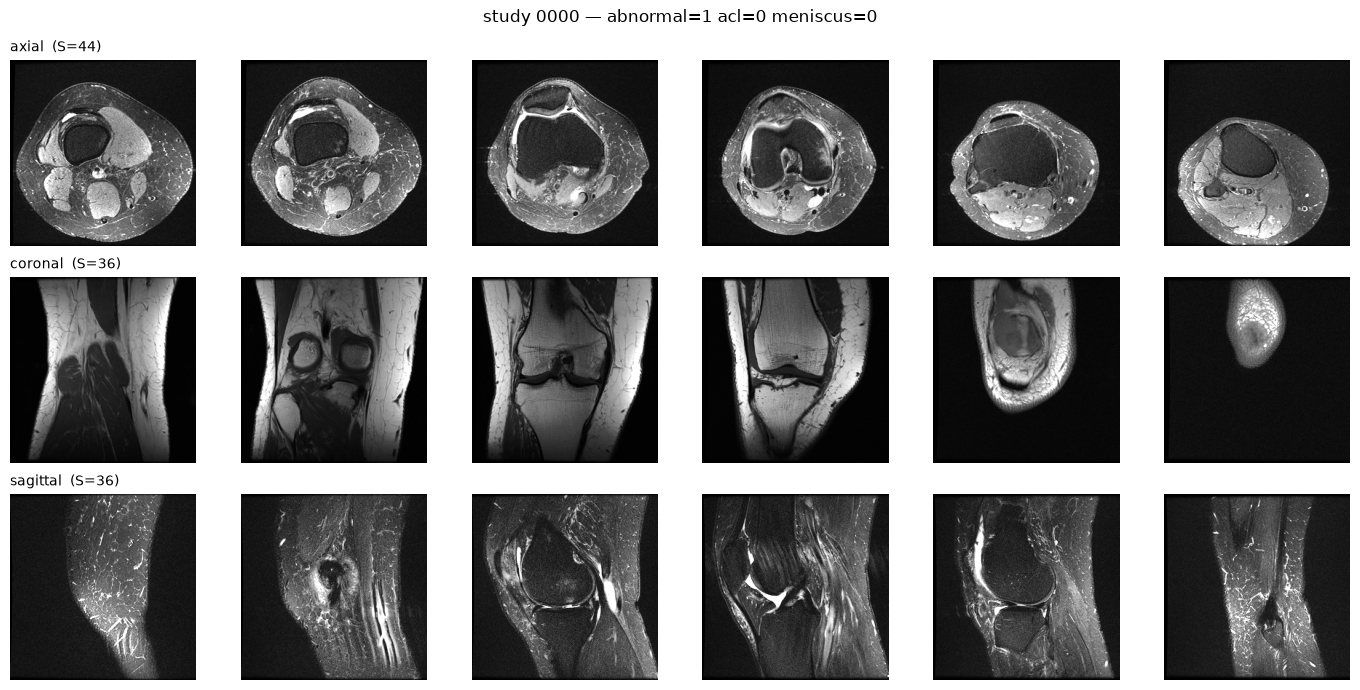

In [24]:
# visual sanity: a slice montage for one study, all three planes
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for r, plane in enumerate(PLANES):
    v = np.load(DATA_ROOT / "train" / plane / f"{train_df.study_id[0]}.npy")
    idx = np.linspace(0, len(v) - 1, 6).astype(int)
    for c, s in enumerate(idx):
        axes[r, c].imshow(v[s], cmap="gray"); axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(f"{plane}  (S={len(v)})", loc="left", fontsize=10)
lab = train_df.iloc[0]
fig.suptitle(f"study {lab.study_id} — abnormal={lab.abnormal} acl={lab.acl} meniscus={lab.meniscus}")
plt.tight_layout(); plt.show()

## 5. The model

```
(S,3,H,W) --AlexNet.features--> (S,256,h,w) --GAP--> (S,256) --POOL over S--> (1,256) --Linear--> logit
```

The whole paper is in that second-to-last arrow. `max` over the slice axis means *"let the most
suspicious slice win"* — a tear visible on 2 of 30 slices survives instead of being averaged into
nothing. Max-pooling works **per feature**: different features can peak on different slices, so the
output vector says *"strong edge-disruption evidence somewhere, strong fluid evidence somewhere"*
even when those somewheres are different slices.

`pooling` is a knob here (`max` is the faithful default) purely so Phase 2 is a one-line change:

- `max` — peak. Great for focal, blind to how *many* slices lit up.
- `mean` — accumulation. Dilutes focal findings.
- `lse` — log-sum-exp, a tunable dial between mean (`r→0`) and max (`r→∞`).
- `attention` — gated attention pooling (Ilse et al. 2018): learn a weight per slice, so the model
  can concentrate on 2 slices *or* spread across 20 depending on the finding.

In [25]:
class GatedAttentionPool(nn.Module):
    def __init__(self, dim=256, hidden=128):
        super().__init__()
        self.V = nn.Linear(dim, hidden)
        self.U = nn.Linear(dim, hidden)
        self.w = nn.Linear(hidden, 1)

    def forward(self, f):                       # f: (S, D)
        a = self.w(torch.tanh(self.V(f)) * torch.sigmoid(self.U(f)))   # (S, 1)
        a = torch.softmax(a, dim=0)
        return (a * f).sum(0, keepdim=True), a.squeeze(1)              # (1, D), (S,)


class MRNet(nn.Module):
    def __init__(self, pooling="max", lse_r=5.0, freeze_backbone=False):
        super().__init__()
        self.backbone = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1).features
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad_(False)
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.pooling    = pooling
        self.lse_r      = lse_r
        self.attn       = GatedAttentionPool(256) if pooling == "attention" else None
        self.classifier = nn.Linear(256, 1)

    def forward(self, x, return_weights=False):     # x: (S, 3, H, W)
        f = self.gap(self.backbone(x)).flatten(1)   # (S, 256)
        w = None
        if self.pooling == "max":
            z = f.max(dim=0, keepdim=True).values
        elif self.pooling == "mean":
            z = f.mean(dim=0, keepdim=True)
        elif self.pooling == "lse":
            r = self.lse_r
            z = torch.logsumexp(r * f, dim=0, keepdim=True) / r - math.log(f.shape[0]) / r
        elif self.pooling == "attention":
            z, w = self.attn(f)
        else:
            raise ValueError(self.pooling)
        logit = self.classifier(z).squeeze(1)       # (1,)
        return (logit, w) if return_weights else logit


_m = MRNet(pooling=CFG.pooling).to(DEVICE)
with torch.no_grad():
    print("forward smoke test ->", _m(_x.to(DEVICE)).item())
print("trainable params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))
del _m

forward smoke test -> 0.6491897106170654
trainable params: 2469953


## 6. Train / eval loops

- **Loss:** `BCEWithLogitsLoss` with `pos_weight = n_neg / n_pos` from the training split (the
  paper's prevalence weighting).
- **Optimiser:** Adam, lr `1e-5` (paper).
- **Model selection:** keep the checkpoint with the best validation AUC — this is the paper's
  early-stopping-on-validation-AUC rule.
- Batch size is 1 *study*; the slice axis carries the real parallelism, so MPS stays busy.

In [26]:
@torch.no_grad()
def predict(model, loader, device=DEVICE):
    model.eval()
    probs, ys = [], []
    for x, y, _ in loader:
        p = torch.sigmoid(model(x.to(device, non_blocking=True)))
        probs.append(p.float().cpu().item()); ys.append(y.item())
    return np.array(probs), np.array(ys)


def safe_auc(y, p):
    return float("nan") if len(np.unique(y)) < 2 else roc_auc_score(y, p)


def train_one(plane, task, cfg=CFG, verbose=True):
    seed_everything(cfg.seed)
    tr_loader = make_loader("train", plane, task, train_df, train=True,  cfg=cfg)
    va_loader = make_loader("valid", plane, task, valid_df, train=False, cfg=cfg)

    n_pos = float(train_df[task].sum()); n_neg = len(train_df) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model = MRNet(cfg.pooling, cfg.lse_r, cfg.freeze_backbone).to(DEVICE)
    opt   = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                             lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.3, patience=2)

    ckpt = Path(cfg.ckpt_dir) / f"{plane}_{task}_{cfg.pooling}.pt"
    best, history = -1.0, []

    for ep in range(cfg.epochs):
        model.train(); t0 = time.time(); tot = 0.0
        for x, y, _ in tr_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.view(1).to(DEVICE)
            loss = crit(model(x), y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.grad_clip:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            tot += loss.item()
        p, yv = predict(model, va_loader)
        auc = safe_auc(yv, p)
        sched.step(auc if auc == auc else 0.0)
        history.append(dict(epoch=ep, loss=tot / len(tr_loader), val_auc=auc,
                            secs=time.time() - t0))
        if auc == auc and auc > best:
            best = auc
            torch.save(model.state_dict(), ckpt)
        if verbose:
            star = " *" if auc == best else ""
            print(f"    ep {ep:>2}  loss {tot/len(tr_loader):.4f}  "
                  f"val_auc {auc:.4f}  {history[-1]['secs']:.0f}s{star}")
        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model, best, history

## 7. Train all 9 CNNs

3 planes × 3 tasks. Nothing is shared between them — that's the paper's design, and it's why this
is the expensive cell.

**Measured MPS timing** (this machine, real 1,130-study train split, 256x256, 17-61 slices):
**0.21 s/study** forward+backward -> **~4 min/epoch/model** -> **~6 h** for the full
9 models x 10 epochs, plus ~15 min for the final prediction pass in section 9.

If that's too long: keep `CFG.quick=True` for a first pass, cut `epochs` to 5 (validation AUC is
usually flat well before 10), or set `freeze_backbone=True`. Checkpoints are written per model as
`{plane}_{task}_{pooling}.pt`, so an interrupted run can be resumed by hand - but note that
re-running this cell retrains from scratch and overwrites them.


In [27]:
results, models, histories = {}, {}, {}
t_start = time.time()

for task in TASKS:
    for plane in PLANES:
        print(f"[{task:>8} | {plane:>8}]")
        m, auc, hist = train_one(plane, task)
        models[(plane, task)] = m
        results[(plane, task)] = auc
        histories[(plane, task)] = hist
        print(f"    best val AUC = {auc:.4f}")

print(f"\ntotal wall time: {(time.time()-t_start)/60:.1f} min")

[abnormal |    axial]
    ep  0  loss 0.2947  val_auc 0.6597  14s *
    best val AUC = 0.6597
[abnormal |  coronal]


FileNotFoundError: [Errno 2] No such file or directory: 'MRNet-v1.0/valid/coronal/1130.npy'

## 8. Per-series AUCs

Each cell is *one plane's opinion on its own*. The paper never reports these individually, but they
tell you which plane carries which finding — and they're the inputs the combiner is about to weight.

In [ ]:
per_series = pd.DataFrame(
    [[results[(p, t)] for p in PLANES] for t in TASKS],
    index=TASKS, columns=PLANES,
).round(4)
per_series["best single plane"] = per_series.max(axis=1)
display(per_series)

fig, axes = plt.subplots(1, len(TASKS), figsize=(14, 3.5), sharey=True)
for ax, task in zip(np.atleast_1d(axes), TASKS):
    for plane in PLANES:
        h = histories[(plane, task)]
        ax.plot([r["epoch"] for r in h], [r["val_auc"] for r in h], marker="o", label=plane)
    ax.set_title(task); ax.set_xlabel("epoch"); ax.grid(alpha=.3)
np.atleast_1d(axes)[0].set_ylabel("val AUC"); np.atleast_1d(axes)[0].legend()
plt.tight_layout(); plt.show()

## 9. The combiner — 3 series → 1 study verdict

For each task, take the three per-plane probabilities for a knee and feed them to a **logistic
regression**: a learned weighted vote. Three numbers in, one number out.

The paper fits this on the training set, which is what `combiner_fit_on="train"` does. Be aware of
the caveat: the CNNs have *seen* those studies, so their train-set probabilities are optimistically
sharp and the fitted weights are slightly biased. `combiner_fit_on="valid_split"` fits on half the
validation set and scores on the other half — less faithful, more honest. Worth reporting both.

In [ ]:
def series_probs(split, df):
    """(n_studies, 3 planes) probability matrix per task, from the best checkpoints."""
    out = {}
    for task in TASKS:
        cols = []
        for plane in PLANES:
            loader = make_loader(split, plane, task, df, train=False)
            p, y = predict(models[(plane, task)], loader)
            cols.append(p)
        out[task] = (np.stack(cols, axis=1), df[task].values.astype(int))
    return out

print("scoring train split…"); P_train = series_probs("train", train_df)
print("scoring valid split…"); P_valid = series_probs("valid", valid_df)

In [ ]:
final, coefs, roc_data = {}, {}, {}
rng = np.random.default_rng(CFG.seed)

for task in TASKS:
    Xtr, ytr = P_train[task]
    Xva, yva = P_valid[task]

    if CFG.combiner_fit_on == "train":
        Xfit, yfit, Xev, yev = Xtr, ytr, Xva, yva
    else:                                    # split the valid set in half
        idx = rng.permutation(len(yva)); h = len(idx) // 2
        Xfit, yfit = Xva[idx[:h]], yva[idx[:h]]
        Xev,  yev  = Xva[idx[h:]], yva[idx[h:]]

    lr = LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced")
    lr.fit(Xfit, yfit)
    p = lr.predict_proba(Xev)[:, 1]

    final[task] = safe_auc(yev, p)
    coefs[task] = dict(zip(PLANES, lr.coef_[0]))
    roc_data[task] = (yev, p)

PAPER = {"abnormal": 0.937, "acl": 0.965, "meniscus": 0.847}
summary = pd.DataFrame({
    "ours (ensemble)":  [final[t] for t in TASKS],
    "ours (best plane)": [per_series.loc[t, "best single plane"] for t in TASKS],
    "paper":            [PAPER[t] for t in TASKS],
}, index=TASKS).round(4)
summary["delta vs paper"] = (summary["ours (ensemble)"] - summary["paper"]).round(4)
print(f"combiner fitted on: {CFG.combiner_fit_on}"
      f"{'   [SYNTHETIC DATA — not comparable to paper]' if CFG.use_synthetic else ''}")
display(summary)

## 10. ROC curves + the interpretability check

The paper's nicest sanity result: when they read the combiner's learned weights, **axial mattered
most for meniscus and coronal for ACL** — matching radiologist intuition. That's the whole argument
for using a 3-parameter logistic regression instead of a fusion network: the weights are *readable*.

If your bar chart reproduces that ordering, the pipeline is wired correctly end to end. (On the
synthetic sandbox it should reproduce it too — that's exactly how the fake signal was planted.)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for task in TASKS:
    y, p = roc_data[task]
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, lw=2, label=f"{task}  AUC={final[task]:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="1 − specificity", ylabel="sensitivity", title="Study-level ROC (validation)")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=.3)

cdf = pd.DataFrame(coefs).T[PLANES]
cdf.plot(kind="bar", ax=axes[1], rot=0)
axes[1].axhline(0, color="k", lw=.8)
axes[1].set(title="Logistic-regression weights per plane", ylabel="coefficient")
axes[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

print("Most-weighted plane per task:")
for task in TASKS:
    print(f"  {task:>8}: {max(coefs[task], key=coefs[task].get)}"
          f"   (paper: acl -> coronal, meniscus -> axial)")
display(cdf.round(3))

In [ ]:
# persist everything so Phase 2 can compare against this run without retraining
run = dict(
    config=asdict(CFG),
    device=str(DEVICE),
    synthetic=CFG.use_synthetic,
    per_series={f"{p}|{t}": results[(p, t)] for p in PLANES for t in TASKS},
    final=final,
    coefs=coefs,
    histories={f"{p}|{t}": histories[(p, t)] for p in PLANES for t in TASKS},
)
out = Path(CFG.ckpt_dir) / f"run_{CFG.pooling}{'_synth' if CFG.use_synthetic else ''}.json"
out.write_text(json.dumps(run, indent=2, default=float))
print("saved ->", out.resolve())

## 11. Phase 2 — where we go from here

The reproduction above is the control condition. Three directions, roughly in order of cost:

### (a) The pooling experiment — the cheapest real research question

> Does the slice-aggregation rule (max / mean / lse / attention) systematically change **which kinds
> of findings** the model detects — focal vs diffuse — and does the wrong choice quietly hurt the
> rare, high-stakes ones?

Mechanically it's `CFG.pooling = "mean"` and re-run — everything else held fixed, checkpoints and
JSON already keyed by pooling name. Run the **synthetic sandbox first**, where you control the
signal geometry: build focal-only and diffuse-only variants with *matched total energy*, so the only
difference between them is spatial distribution. The publishable result is the **interaction**
(pooling × finding type), not overall accuracy — "max beats mean by 0.09 on focal but 0.01 on
diffuse" is the shape you want. Then confirm on real MRNet, where `abnormal` is the diffuse-ish task
and the two tear labels are focal.

### (b) Modernise the backbone

AlexNet is 2012. Swap `self.backbone` for ResNet-18/EfficientNet-B0 features (change the `256` in
`gap`/`classifier`/`GatedAttentionPool` to the new feature dim) — or go to a 3D/attention encoder
that sees the slice axis directly instead of collapsing it late.

### (c) The domain-shift angle — the one that matters for OrthoVision

The paper's headline weakness: ACL AUC fell **0.96 → 0.824** on an external hospital (Croatia,
Siemens, T1 instead of T2) with no retraining, recovering to only 0.911 after fine-tuning. MRNet was
1 hospital; the RSNA competition test set spans **16 institutions across 5 continents**. Whatever
number this notebook prints will *overstate* cross-site performance.

Two concrete follow-ons:
- Evaluate these checkpoints on the public **KneeMRI (Croatia/Rijeka)** set to re-measure that drop
  yourself, and test whether a different pooling rule degrades more or less gracefully across sites.
- The fixed-3 logistic regression **won't transfer** to ragged real-world data (some knees have 4
  series, some 6, some missing a plane). Replace it with attention pooling at the *series* level too
  — same "collapse a group into one summary" move, one rung higher, but tolerant of variable set
  size. That's a concrete architectural contribution rather than a re-run.

---

*Data-provenance note worth carrying into OrthoVision:* the Redivis copy of MRNet silently lost
one study per label file to CSV header inference, and a bulk zip truncated without erroring.
Both were invisible until counted. With 16 institutions feeding the RSNA set, make the
count-and-verify step (`verify_dataset()` in §0) a standing gate before any training run.
